In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

In [83]:
from sklearn.impute import SimpleImputer


In [84]:
data = pd.read_parquet('regions_final_checkpoint.parquet')
data.head()

,Region,Country,Crop,Latitude,Longitude,Year,T2M,T2M_MAX,T2M_MIN,RH2M,PRECTOTCORR,WS2M,ALLSKY_SFC_SW_DWN,soil_temperature_0_to_7cm,soil_temperature_7_to_28cm,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm
0,İstanbul,Türkiye,Wheat,41.2506,29.5094,2023-01-01,16.182630,17.175781,15.232110,80.475014,2.049370,4.770137,14.233616,16.692226,16.692169,0.288007,0.286300
1,İstanbul,Türkiye,Barley,41.3800,29.1721,2023-01-01,16.182630,17.175781,15.232110,80.475014,2.049370,4.770137,14.233616,16.695959,16.696233,0.285911,0.285165
2,İstanbul,Türkiye,Maize (corn),40.8898,29.9670,2023-01-01,14.773178,19.958959,10.612384,78.871096,2.715726,2.276274,14.410082,15.832728,15.811747,0.284012,0.272278
3,İstanbul,Türkiye,Apples,40.3204,29.8792,2023-01-01,13.452274,19.634384,8.574356,75.705288,2.244384,1.428493,14.410082,14.027728,13.990776,0.268820,0.254041
4,İstanbul,Türkiye,Olives,40.7145,29.8818,2023-01-01,13.452274,19.634384,8.574356,75.705288,2.244384,1.428493,14.410082,16.735788,16.711438,0.315766,0.312187


In [85]:
df = data.copy()

In [86]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 810 entries, 0 to 809
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Region                      810 non-null    str           
 1   Country                     810 non-null    str           
 2   Crop                        810 non-null    str           
 3   Latitude                    810 non-null    float64       
 4   Longitude                   810 non-null    float64       
 5   Year                        810 non-null    datetime64[us]
 6   T2M                         810 non-null    float64       
 7   T2M_MAX                     810 non-null    float64       
 8   T2M_MIN                     810 non-null    float64       
 9   RH2M                        810 non-null    float64       
 10  PRECTOTCORR                 810 non-null    float64       
 11  WS2M                        810 non-null    float64       
 12  ALLSK

In [87]:
# Tahmin etmek istediğiniz hedef değişkeni buraya yazın.
# Örneğin: 'Crop' sınıflandırma için, 'Yield' gibi bir sayı hedefi regresyon için.
target_column = 'Crop'

y = df[target_column]

# Eğer bazı sütunları özellik olarak kullanmak istemezseniz, buraya ekleyin.
exclude_cols = ['Latitude', 'Longitude']
X = df.drop(columns=[target_column]+ exclude_cols)
X = X.drop(columns=[c for c in exclude_cols if c in X.columns], errors='ignore')

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Feature columns:', X.columns.tolist())
print('Target column:', target_column)


X shape: (810, 14)
y shape: (810,)
Feature columns: ['Region', 'Country', 'Year', 'T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'PRECTOTCORR', 'WS2M', 'ALLSKY_SFC_SW_DWN', 'soil_temperature_0_to_7cm', 'soil_temperature_7_to_28cm', 'soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm']
Target column: Crop


In [88]:
# Model eğitiminden hemen önce:
X['Year'] = pd.to_datetime(X['Year']).dt.year
# Artık numeric_features içine eklenebilir, categorical_features'dan çıkarılabilir.

In [89]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = ['Region', 'Country']

In [90]:


numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [91]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [92]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cut', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    verbose=False
)

In [93]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, train_size=0.8, test_size=0.2)


In [102]:
X_train_processed = preprocessor.fit_transform(X_train) # Öğren ve uygula (93 sütun)
X_test_processed = preprocessor.transform(X_test)

In [103]:
# Sayısal ve kategorik sütunları otomatik seçelim
numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'datetime']).columns.tolist()

# ÖNEMLİ: Eğer 'Year' sütunu datetime ise onu sayıya çevirmek karmaşayı önler
if 'Year' in X.columns and X['Year'].dtype == 'datetime64[ns]':
    X['Year'] = X['Year'].dt.year
    # Year artık sayısal olduğu için listeleri güncelleyelim
    if 'Year' not in numeric_features: numeric_features.append('Year')
    if 'Year' in categorical_features: categorical_features.remove('Year')

C:\Users\Musa Halil Ecer\AppData\Local\Temp\ipykernel_26604\332871139.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object', 'datetime']).columns.tolist()


In [104]:
# 1. Tüm yapıyı eğit (fit et)
preprocessor.fit(X)

# 2. EN TEMİZ YOL: Doğrudan preprocessor'dan tüm isimleri iste
# Bu komut sayısal isimleri korur, kategorikleri OneHot formatına çevirir ve birleştirir.
all_feature_names = preprocessor.get_feature_names_out()

print(f"Toplam özellik sayısı: {len(all_feature_names)}")
print(all_feature_names)

Toplam özellik sayısı: 93
['cut__T2M' 'cut__T2M_MAX' 'cut__T2M_MIN' 'cut__RH2M' 'cut__PRECTOTCORR'
 'cut__WS2M' 'cut__ALLSKY_SFC_SW_DWN' 'cut__soil_temperature_0_to_7cm'
 'cut__soil_temperature_7_to_28cm' 'cut__soil_moisture_0_to_7cm'
 'cut__soil_moisture_7_to_28cm' 'cat__Region_Adana' 'cat__Region_Adıyaman'
 'cat__Region_Afyonkarahisar' 'cat__Region_Aksaray' 'cat__Region_Amasya'
 'cat__Region_Ankara' 'cat__Region_Antalya' 'cat__Region_Ardahan'
 'cat__Region_Artvin' 'cat__Region_Aydın' 'cat__Region_Ağrı'
 'cat__Region_Balıkesir' 'cat__Region_Bartın' 'cat__Region_Batman'
 'cat__Region_Bayburt' 'cat__Region_Bilecik' 'cat__Region_Bingöl'
 'cat__Region_Bitlis' 'cat__Region_Bolu' 'cat__Region_Burdur'
 'cat__Region_Bursa' 'cat__Region_Denizli' 'cat__Region_Diyarbakır'
 'cat__Region_Düzce' 'cat__Region_Edirne' 'cat__Region_Elazığ'
 'cat__Region_Erzincan' 'cat__Region_Erzurum' 'cat__Region_Eskişehir'
 'cat__Region_Gaziantep' 'cat__Region_Giresun' 'cat__Region_Gümüşhane'
 'cat__Region_Hakkari' 

In [105]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Support Vector Machine": SVC()
}

In [109]:
results = []

In [107]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [110]:
for name, model in models.items():
    # Eğitim
    model.fit(X_train_processed, y_train)
    
    # Tahmin
    y_pred = model.predict(X_test_processed)
    
    # Metrikleri hesaplama
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1-Score": f1_score(y_test, y_pred, average='weighted')
    })

c:\Project\Smart_Agriculture_Project\model\notebook\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [111]:
comparison_df = pd.DataFrame(results)
print(comparison_df.sort_values(by="Accuracy", ascending=False))

                    Model  Accuracy  Precision    Recall  F1-Score
2  Support Vector Machine  0.049383   0.065384  0.049383  0.031936
1     K-Nearest Neighbors  0.043210   0.021973  0.043210  0.027824
0      LogisticRegression  0.000000   0.000000  0.000000  0.000000


In [112]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [113]:
kmenas = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmenas.fit_predict(X_train_processed)

sil_score = silhouette_score(X_train_processed, clusters)
print(f"K-Means Silhouette Skoru: {sil_score}")

K-Means Silhouette Skoru: 0.32545664975018274


In [115]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(probability=True)
}

results = []
for name, model in models.items():
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred, average='weighted'),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted')
    })

comparison_df = pd.DataFrame(results).melt(id_vars="Model", var_name="Metric", value_name="Score")

c:\Project\Smart_Agriculture_Project\model\notebook\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


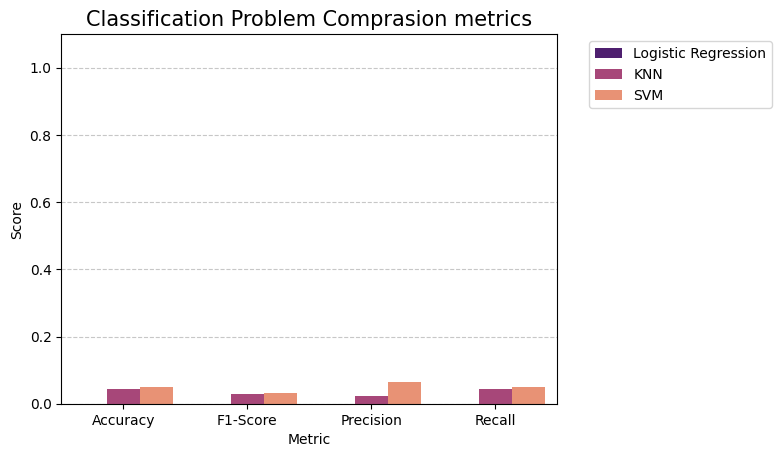

In [116]:
plt.Figure(figsize=(12,6))
sns.barplot(data=comparison_df, x="Metric", y="Score", hue="Model", palette="magma")
plt.title("Classification Problem Comprasion metrics", fontsize=15)
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [117]:
best_model = models["Logistic Regression"]
y_pred_best = best_model.predict(X_test_processed)
cm = confusion_matrix(y_test, y_pred_best)
labels = sorted(y.unique())

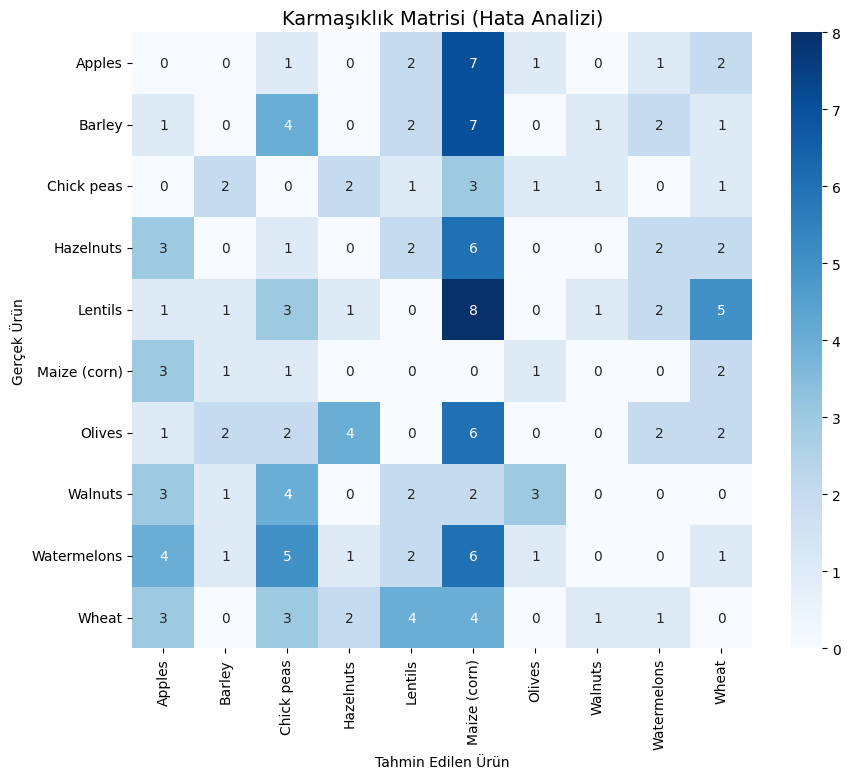

In [118]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Karmaşıklık Matrisi (Hata Analizi)", fontsize=14)
plt.xlabel("Tahmin Edilen Ürün")
plt.ylabel("Gerçek Ürün")
plt.show()

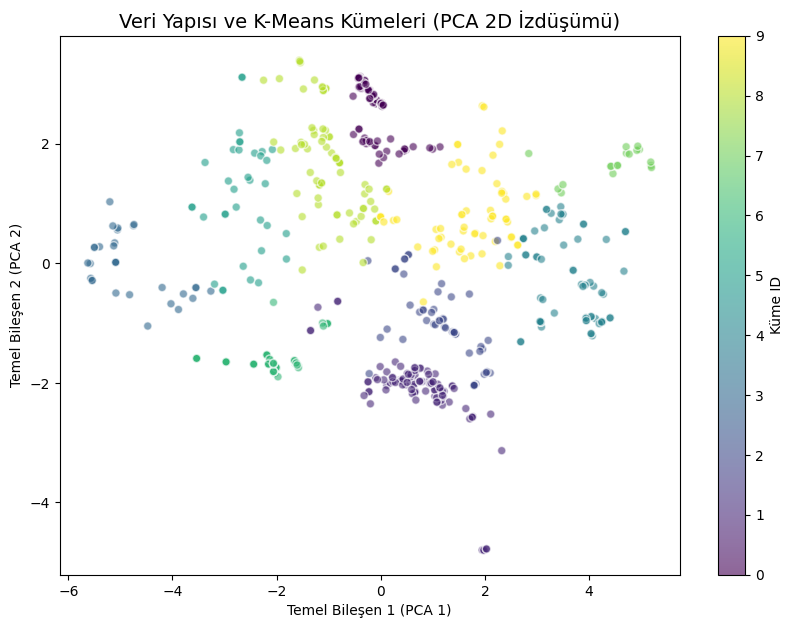

In [120]:
from sklearn.decomposition import PCA


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_processed)

# K-Means ile 5 küme oluşturma (Ürün sayısı kadar seçilebilir)
kmeans = KMeans(n_clusters=len(labels), random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_train_processed)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6, edgecolors='w')
plt.title("Veri Yapısı ve K-Means Kümeleri (PCA 2D İzdüşümü)", fontsize=14)
plt.xlabel("Temel Bileşen 1 (PCA 1)")
plt.ylabel("Temel Bileşen 2 (PCA 2)")
plt.colorbar(scatter, label="Küme ID")
plt.show()

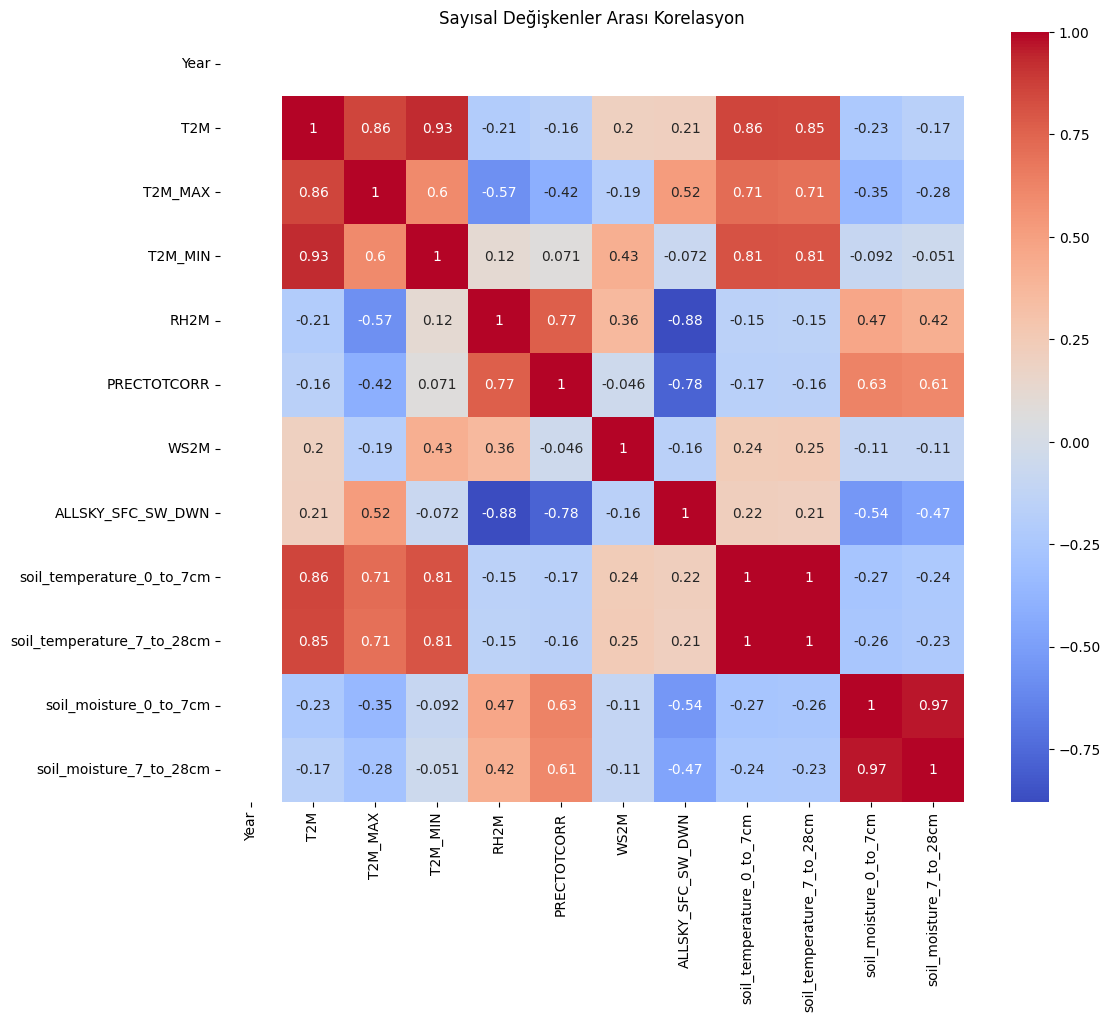

In [122]:
plt.figure(figsize=(12,10))
sns.heatmap(df[numeric_features].corr(), annot=True, cmap='coolwarm')
plt.title("Sayısal Değişkenler Arası Korelasyon")
plt.show()

In [124]:
import joblib
from matplotlib.pyplot import clf

# Eğer bir Pipeline kullandıysan en garantisi budur:
joblib.dump(clf, 'final_agriculture_model_pipeline.pkl')

# Eğer ayrı ayrı kaydetmek istersen:
joblib.dump(preprocessor, 'preprocessor.pkl')
joblib.dump(best_model, 'logistic_model.pkl')

['logistic_model.pkl']

In [125]:
# Her plot komutundan sonra (plt.show() demeden önce):
plt.savefig('model_comparison_plot.png', dpi=300, bbox_inches='tight')
plt.savefig('confusion_matrix.pdf') # Vektörel format için PDF harikadır

<Figure size 640x480 with 0 Axes>